# TOPP-HATT

In some cases, we want to optimise an encoding without changing the underlying tree structure. For instance, we may want to use exactly the tree output from the [Bonsai Algorithm](https://ferrmion.readthedocs.io/en/latest/notebooks/bonsai.html).

`ferrmion` lets you do this with the `topphatt` algorithm.

This notebook demonstrates the benefits of the method, for simple examples of how to use it, please see the documentation on [encoding Hamiltonians with ferrmion.](https://ferrmion.readthedocs.io/en/latest/notebooks/encoding_hamiltonians.html).

For more details about the method itself, see our [preprint](https://arxiv.org/abs/2512.13580).

In [1]:
import ferrmion as fr
from ferrmion import core
from ferrmion.core import fermionic_to_sparse_majorana
import numpy.random as rng
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from copy import deepcopy
import json

We'll start as always by loading in some one and two electron integrals.

In [2]:
folder = Path.cwd().joinpath(Path("../../../python/tests/data/"))

# Takes a little too long to run for readthedocs
# with open(folder.joinpath("h2o_6-31g.json"), 'r') as file:
#     data = json.load(file)

with open(folder.joinpath("h2o_sto-3g.json"), 'r') as file:
    data = json.load(file)

ones = np.array(data["ones"])
twos = np.array(data["twos"])
enuc = data["constant_energy"]

In [3]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (int(np.sum(unscaled_terms)), float(np.sum(scaled_terms)), len(pauli_hamiltonian))

In [7]:
from ferrmion.visualise import symplectic_matshow
def get_naive_result(tree:fr.TernaryTree, fham: fr.FermionHamiltonian):
    print("Getting Naive result...")
    sdmeans_naive = {}
    ipow, sym = tree._build_symplectic_matrix()
    result = pauli_weights(tree.encode(fham))
    print("Naive result:", result)

    sdmeans_naive = {}
    sdmeans_naive["unscaled"] = result[0]
    sdmeans_naive["scaled"] = result[1]
    sdmeans_naive["length"] = result[2]
    return sdmeans_naive

def get_permuation_results(tree: fr.FermionQubitEncoding,fham: fr.FermionHamiltonian, limit:int):
    print(f"\nGetting {limit} random results...")
    sdmeans = {}
    sdmeans = {"unscaled":[], "scaled":[]}
    weights = tree._batch_pauli_weights(fham, limit)
    sdmeans["unscaled"] = [w for w in weights[0]]
    sdmeans["scaled"] = [w for w in weights[1]]
    print("Permutation Results")

    return sdmeans

def get_annealed_result(tree, fham, coef_weight):
    # To avoid re-annealing between weighted and unweighted
    encoding = fr.MajoranaStringEncoding(*tree._build_symplectic_matrix())
    print("\nGetting Annealed result...")
    sdmeans_annealed = {}
    sdmeans_annealed = {"unscaled":[], "scaled":[], "length":[]}
    result = pauli_weights(encoding.encode_annealed(fham, coefficient_weighted=coef_weight))
    print("Annealed result:", result)
    sdmeans_annealed["unscaled"].append(result[0])
    sdmeans_annealed["scaled"].append(result[1])
    sdmeans_annealed["length"].append(result[2])
    return sdmeans_annealed

def get_rust_topphatt_result(tree, fham, n_random=10):
    print("\nRunning rust TOPP-HATT...")

    results = {}
    for heuristic in ("min_weight", "z_first", "x_first"):
        print(f"\nGetting rust TOPP-HATT result (heuristic={heuristic})...")
        result = pauli_weights(tree.encode_topphatt(fham, heuristic=heuristic))
        print(f"TOPP-HATT {heuristic} result:", result)
        results[heuristic] = {
            "unscaled": result[0],
            "scaled": result[1],
            "length": result[2],
        }

    print(f"\nGetting {n_random} rust TOPP-HATT random results...")
    random_results = {"unscaled": [], "scaled": [], "length": []}
    for seed in range(n_random):
        result = pauli_weights(
            tree.encode_topphatt(fham, heuristic="random", seed=seed)
        )
        print(f"TOPP-HATT random seed={seed} result:", result)
        random_results["unscaled"].append(result[0])
        random_results["scaled"].append(result[1])
        random_results["length"].append(result[2])
    results["random"] = random_results

    return results

def get_topp_hatt_results(tree: fr.TernaryTree, name, ones, twos, enuc, limit=1000, save=False):
    fham = fr.molecular_hamiltonian(ones, twos, enuc)

    sdmeans_naive = get_naive_result(tree, fham)
    sdmeans = get_permuation_results(tree, fham, limit)

    sdmeans_annealed_pw = get_annealed_result(tree, fham, False)
    sdmeans_annealed_cpw = get_annealed_result(tree, fham, True)

    sdmeans_topphatt = get_rust_topphatt_result(tree, fham)

    color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
    fig, ax = plt.subplots(layout="constrained")

    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label="Randomised Permutations", marker=".", color="tab:grey", alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color="tab:red", mec="k", markersize=8)
    ax.plot(sdmeans_annealed_pw["unscaled"], sdmeans_annealed_pw["scaled"], marker="P", color="tab:orange", mec="k", markersize=8)
    ax.plot(sdmeans_annealed_cpw["unscaled"], sdmeans_annealed_cpw["scaled"], marker="X", color="tab:orange", mec="k", markersize=8)

    topphatt_heuristic_styles = {
        "min_weight": ("P", "tab:green"),
        "z_first": ("^", "tab:green"),
        "x_first": ("v", "tab:green"),
    }
    for heuristic, (marker, color) in topphatt_heuristic_styles.items():
        ax.plot(
            sdmeans_topphatt[heuristic]["unscaled"],
            sdmeans_topphatt[heuristic]["scaled"],
            marker=marker,
            linestyle="",
            color=color,
            mec="k",
            markersize=8,
        )
    ax.scatter(
        sdmeans_topphatt["random"]["unscaled"],
        sdmeans_topphatt["random"]["scaled"],
        marker="*",
        color="tab:green",
        edgecolor="k",
        s=80,
        label="TOPP-HATT random",
    )

    # where some data has already been plotted to ax
    handles, labels = plt.gca().get_legend_handles_labels()
    # manually define a new patch
    naive_legend = mlines.Line2D([], [], label='Naive Enumeration', marker="D", linestyle="", color="tab:red", mec="k", markersize=8)
    annealed_pw_legend = mlines.Line2D([], [], label='$W_{P}$ Annealed Best', marker="P", linestyle="",color="tab:orange", mec="k", markersize=8)
    annealed_cpw_legend = mlines.Line2D([], [], label='$W_{CP}$ Annealed Best', marker="X", linestyle="",color="tab:orange", mec="k", markersize=8)
    topphatt_best_legend = mlines.Line2D([], [], label='TOPP-HATT min_weight', marker="P", linestyle="", color="tab:green", mec="k", markersize=8)
    topphatt_zfirst_legend = mlines.Line2D([], [], label='TOPP-HATT z_first', marker="^", linestyle="", color="tab:green", mec="k", markersize=8)
    topphatt_xfirst_legend = mlines.Line2D([], [], label='TOPP-HATT x_first', marker="v", linestyle="", color="tab:green", mec="k", markersize=8)


    data = {"random":sdmeans, "naive":sdmeans_naive, "annealed_pw":sdmeans_annealed_pw, "annealed_cpw":sdmeans_annealed_cpw, "topphatt":sdmeans_topphatt}
    if save:
        with open(f"{name}.json", "w+") as f:
            json.dump(data, f)

    # handles is a list, so append manual patch
    handles.extend([
                    naive_legend,
                    annealed_pw_legend,
                    annealed_cpw_legend,
                    topphatt_best_legend,
                    topphatt_zfirst_legend,
                    topphatt_xfirst_legend,
                    ])

    ax.set_xlabel("unscaled pauli-weight")
    ax.set_ylabel("coefficient scaled pauli-weight")
    ax.set_title(f"{name} Encodings of $H_2 O$:$STO-3G$")
    fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)
    fig.show()


# Standard Encodings

Getting Naive result...
Naive result: (14756, 191.34214293107772, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (12156, 151.83799364115615, 2034)

Getting Annealed result...
Annealed result: (13926, 143.4561963144714, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (10946, 146.7504104149034, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (10946, 146.75041041490343, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (10946, 146.7504104149034, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (10946, 146.7504104149034, 2034)
TOPP-HATT random seed=1 result: (10946, 146.7504104149034, 2034)
TOPP-HATT random seed=2 result: (10946, 146.7504104149034, 2034)
TOPP-HATT random seed=3 result: (10946, 146.7504104149034, 2034)
TOPP-HATT random seed=4 result: (10946, 1

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_80688/2830229034.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


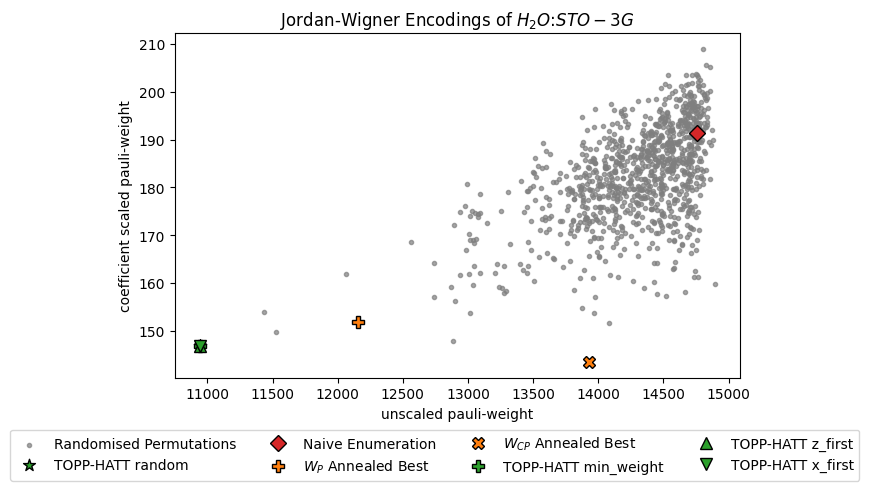

In [8]:
get_topp_hatt_results(fr.JordanWigner(ones.shape[0]),"Jordan-Wigner", ones, twos, enuc)

Getting Naive result...
Naive result: (15047, 256.80196979954786, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (12444, 219.71328200702197, 2034)

Getting Annealed result...
Annealed result: (14478, 198.42890971553405, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (11432, 213.3802763503185, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (11432, 213.38027635031847, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (11432, 213.3802763503185, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (11432, 213.38027635031847, 2034)
TOPP-HATT random seed=1 result: (11432, 213.38027635031847, 2034)
TOPP-HATT random seed=2 result: (11432, 213.38027635031847, 2034)
TOPP-HATT random seed=3 result: (11432, 213.38027635031847, 2034)
TOPP-HATT random seed=4 result: (114

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_80688/2830229034.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


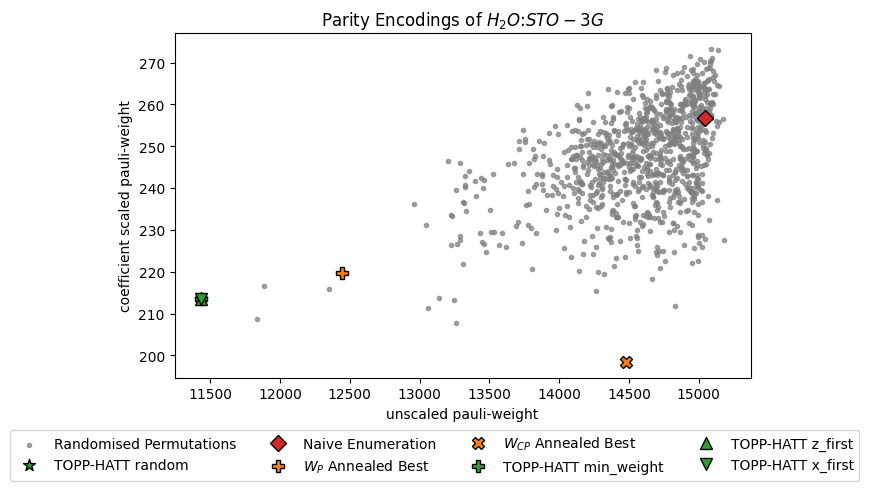

In [9]:
get_topp_hatt_results(fr.ParityEncoding(ones.shape[0]),"Parity", ones, twos, enuc)


Getting Naive result...
Naive result: (12656, 292.0322457722771, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (12054, 235.13106577517584, 2034)

Getting Annealed result...
Annealed result: (12492, 184.68565167631252, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (12470, 194.68983960393956, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (12369, 196.50921893984474, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (12470, 194.68983960393956, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (12734, 198.09391484849107, 2034)
TOPP-HATT random seed=1 result: (12514, 201.91953163332693, 2034)
TOPP-HATT random seed=2 result: (12470, 196.20541182477626, 2034)
TOPP-HATT random seed=3 result: (12540, 204.28607220366925, 2034)
TOPP-HATT random seed=4 result: (12

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_80688/2830229034.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


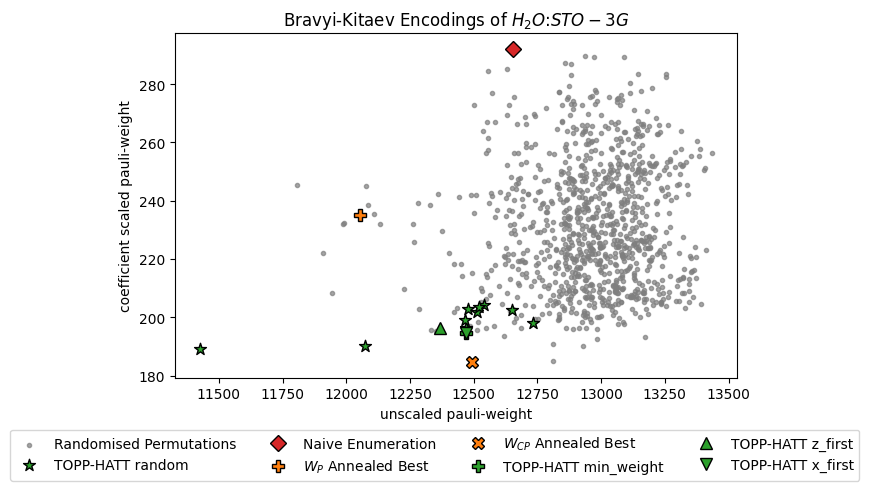

In [10]:
get_topp_hatt_results(fr.BravyiKitaev(ones.shape[0]),"Bravyi-Kitaev", ones, twos, enuc)

Getting Naive result...
Naive result: (12718, 277.8229667626987, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (12126, 217.78554122230872, 2034)

Getting Annealed result...
Annealed result: (12173, 180.82424466452528, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (11952, 219.94392170372242, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (12108, 198.4682364320475, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (11888, 246.97215488942217, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (11732, 208.8715591075266, 2034)
TOPP-HATT random seed=1 result: (11998, 189.07069819256358, 2034)
TOPP-HATT random seed=2 result: (12108, 190.8852081705467, 2034)
TOPP-HATT random seed=3 result: (11906, 217.57075590379142, 2034)
TOPP-HATT random seed=4 result: (12154

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_80688/2830229034.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


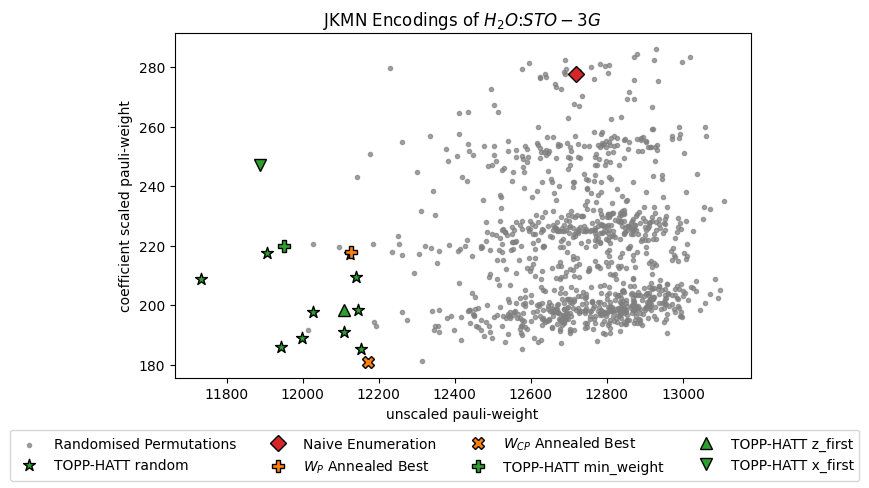

In [11]:
get_topp_hatt_results(fr.JKMN(ones.shape[0]),"JKMN", ones, twos, enuc)


# Hamiltonian Optimized Trees

TOPP-HATT can be applied to any ternary tree,  including those which are derived from other optimisation methods.

In [10]:
from ferrmion.optimize import huffman_ternary_tree
huffman_tree = huffman_ternary_tree(ones, twos)

Getting Naive result...
Naive result: (12974, 205.52406742880447, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (11989, 204.24462649427954, 2034)

Getting Annealed result...
Annealed result: (12345, 184.9609152152548, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=best)...
TOPP-HATT best result: (12303, 195.02453024144614, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (12293, 200.5168995796958, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (12041, 188.55545205208762, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (12564, 202.222972541409, 2034)
TOPP-HATT random seed=1 result: (12665, 199.54625985857848, 2034)
TOPP-HATT random seed=2 result: (12354, 203.0717384474894, 2034)
TOPP-HATT random seed=3 result: (12045, 194.97037437388087, 2034)
TOPP-HATT random seed=4 result: (12666, 207.7099576

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_69149/1255078268.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


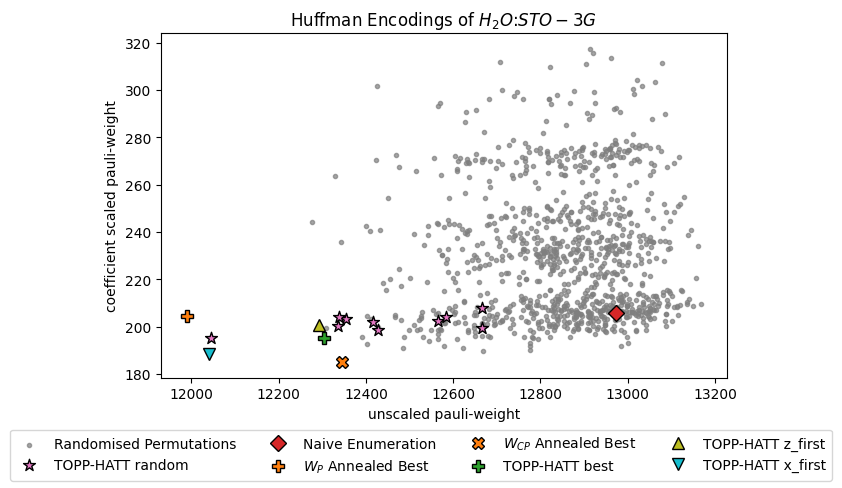

In [11]:
huffman_topphatt = get_topp_hatt_results(huffman_tree, name="Huffman", ones=ones,twos=twos,enuc=enuc)

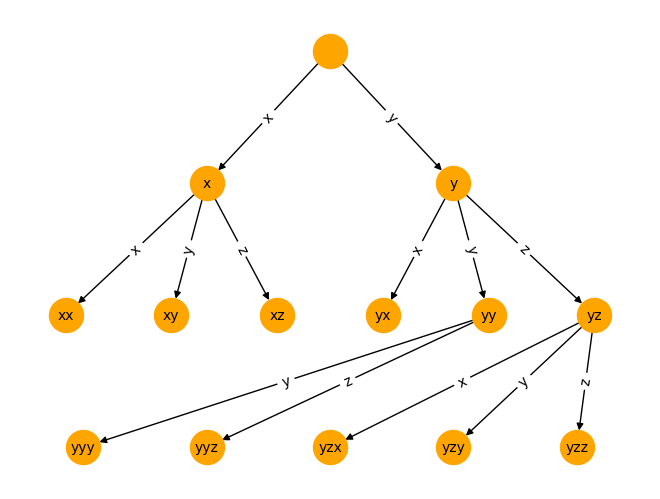

In [12]:
from ferrmion.visualise import draw_tt
draw_tt(huffman_tree)

Getting Naive result...
Naive result: (11169, 170.7429020713822, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (11169, 170.74290207138216, 2034)

Getting Annealed result...
Annealed result: (11165, 169.16971617681978, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=best)...
TOPP-HATT best result: (12454, 188.25547815427296, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (12454, 195.43442588704556, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (12410, 186.75559934592965, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (12454, 190.0536111825724, 2034)
TOPP-HATT random seed=1 result: (12454, 195.43442588704556, 2034)
TOPP-HATT random seed=2 result: (12406, 187.58513005914858, 2034)
TOPP-HATT random seed=3 result: (12464, 193.07657109162642, 2034)
TOPP-HATT random seed=4 result: (12444, 189.9195

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_69149/1255078268.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


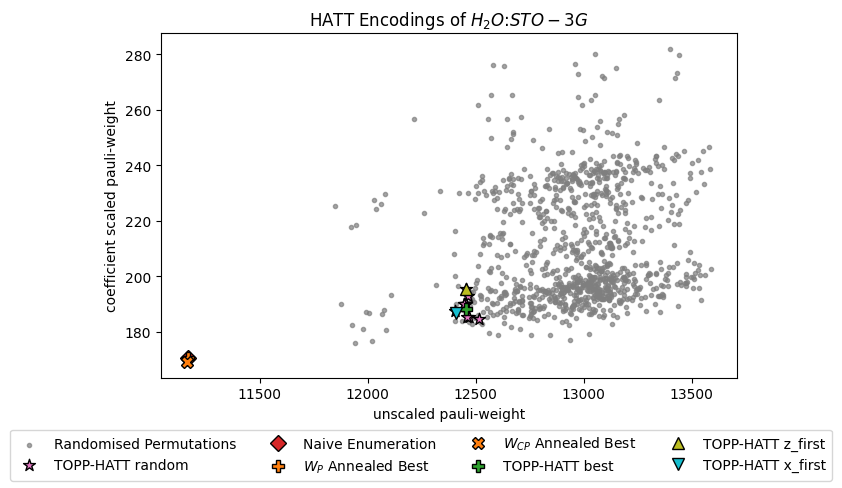

In [13]:
from ferrmion.optimize import hamiltonian_adaptive_ternary_tree
sparse_ham = fermionic_to_sparse_majorana(["+-","++--"],[ones,twos],0)
hatt_tree = hamiltonian_adaptive_ternary_tree(sparse_ham, ones.shape[0])
get_topp_hatt_results(hatt_tree, "HATT", ones=ones, twos=twos, enuc=enuc)

(None,
 {'': (0, 13),
  'x': (1, 5),
  'y': (2, 6),
  'z': (3, 12),
  'zx': (4, 11),
  'zz': (5, 2),
  'zxx': (6, 10),
  'zxy': (7, 8),
  'zzz': (8, 1),
  'zxxx': (9, 3),
  'zxxy': (10, 9),
  'zxxz': (11, 7),
  'zzzz': (12, 0),
  'zxxyz': (13, 4)})

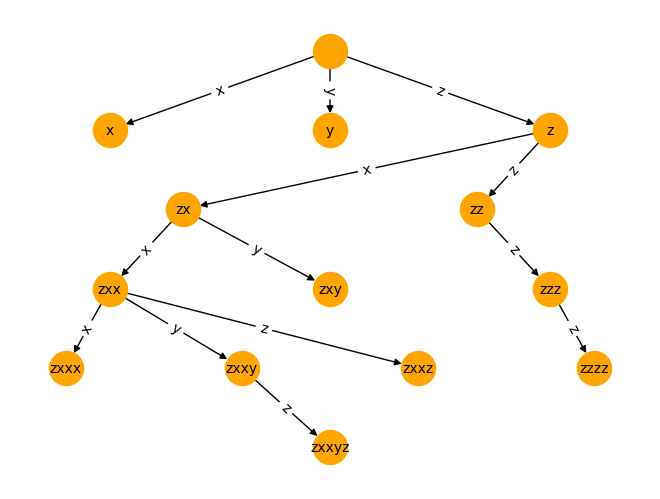

In [14]:
draw_tt(hatt_tree,type="spaced"), hatt_tree.enumeration_scheme

# Device Optimized Trees

In [15]:
import rustworkx as rx
from rustworkx import visualization as rxv
import matplotlib.pyplot as plt
import numpy as np
def heavy_hex_graph():
    graph = rx.PyGraph()
    graph.add_nodes_from(range(ones.shape[0]))
    graph.add_edges_from_no_data(
        [(a,b) for a, b in [
            (0, 1),
            (0, 2),
            (0, 3),
            (1, 4),
            (2, 5),
            (3, 6),
            (4, 7),
            (4, 8),
            (5, 9),
            (5, 10),
            (6, 11),
            (6, 12),
            (7, 13),
            (8, 14),
            (9, 15),
            (10, 16),
            (11, 17),
            (12, 18),
            (13, 19),
            (13, 20),
            (14, 21),
            (14, 22),
            (15, 23),
            (15, 24),
            (16, 25),
            (16, 26),
            (17, 27),
            (17, 28),
            (18, 29),
            (18, 30),
            (22, 31),
            (26, 32),
            (30, 33),
            (31, 34),
            (32, 35),
            (33, 36),
        ] if a<ones.shape[0] and b <ones.shape[1]]
    )
    return graph

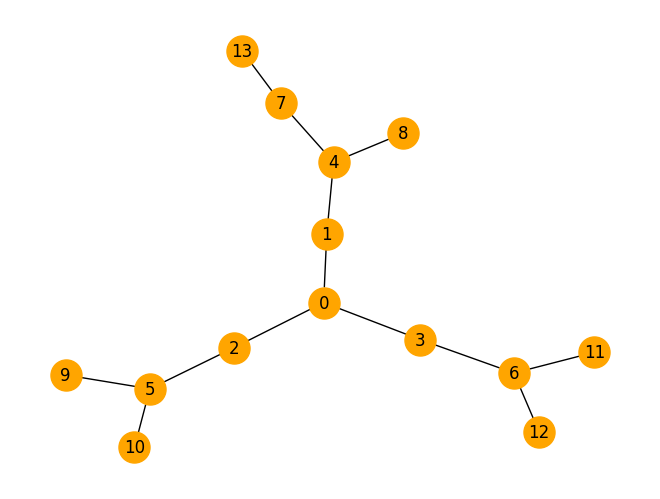

In [16]:
graph = heavy_hex_graph()
rxv.mpl_draw(graph, with_labels=True, node_color="orange", node_size=500)

Getting Naive result...
Naive result: (13584, 280.2418348673023, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (12573, 258.90746414596407, 2034)

Getting Annealed result...
Annealed result: (12931, 166.42749955844354, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=best)...
TOPP-HATT best result: (12508, 185.10596061584224, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (12507, 181.35158280117804, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (13145, 200.9706396000576, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (13184, 267.00895784952223, 2034)
TOPP-HATT random seed=1 result: (12963, 206.70610519947135, 2034)
TOPP-HATT random seed=2 result: (12841, 200.3181713061611, 2034)
TOPP-HATT random seed=3 result: (13172, 213.72418401915138, 2034)
TOPP-HATT random seed=4 result: (12975, 211.18779

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_69149/1255078268.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


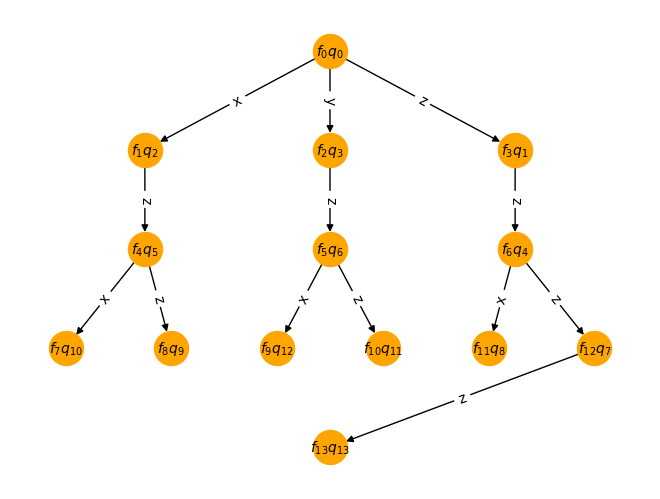

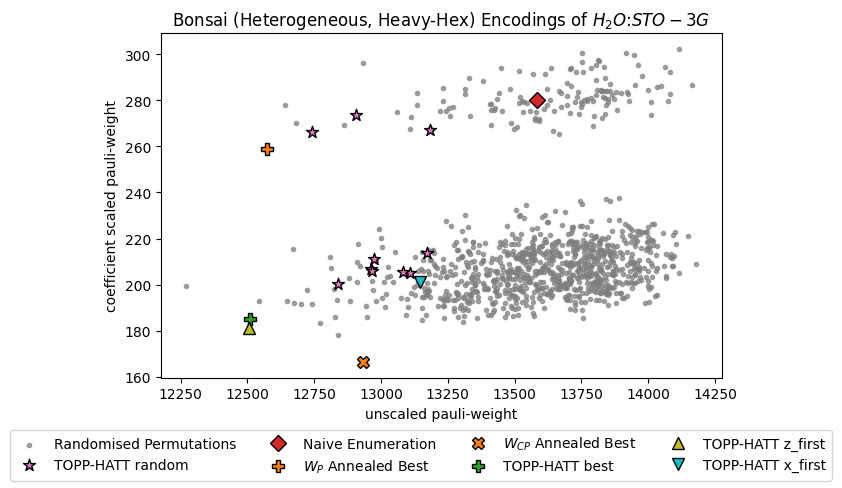

In [17]:
from ferrmion.visualise import draw_tt
from ferrmion.optimize import bonsai_algorithm
bonsai= bonsai_algorithm(graph=graph, homogenous=False)
draw_tt(bonsai, type="spaced", enumeration_scheme=bonsai.default_enumeration_scheme())
get_topp_hatt_results(bonsai, name="Bonsai (Heterogeneous, Heavy-Hex)", ones=ones, twos=twos, enuc=enuc)

Getting Naive result...
Naive result: (13980, 254.09338772672675, 2034)

Getting 1000 random results...
Permutation Results

Getting Annealed result...
Annealed result: (12251, 214.9469233280762, 2034)

Getting Annealed result...
Annealed result: (13769, 188.2272412181474, 2034)

Running rust TOPP-HATT...

Getting rust TOPP-HATT result (heuristic=best)...
TOPP-HATT best result: (12935, 220.46590542424883, 2034)

Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (13004, 214.5542419886807, 2034)

Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (13187, 247.85090268775517, 2034)

Getting 10 rust TOPP-HATT random results...
TOPP-HATT random seed=0 result: (13017, 207.01833129819346, 2034)
TOPP-HATT random seed=1 result: (12947, 220.5349141800736, 2034)
TOPP-HATT random seed=2 result: (12814, 196.05667717260923, 2034)
TOPP-HATT random seed=3 result: (12969, 230.12945736959313, 2034)
TOPP-HATT random seed=4 result: (13285, 196.573349

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_69149/1255078268.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


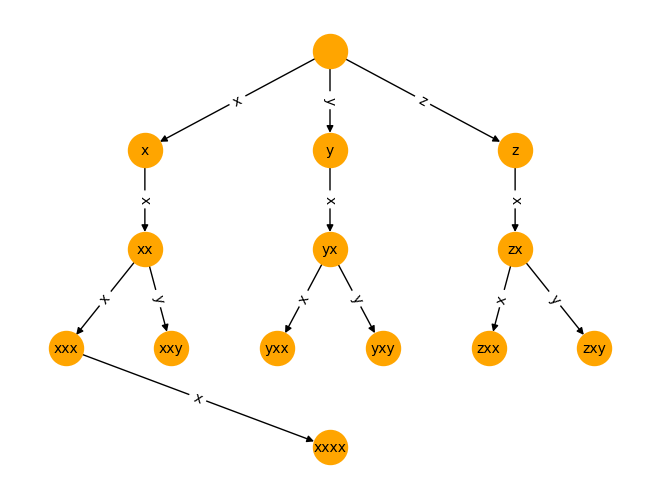

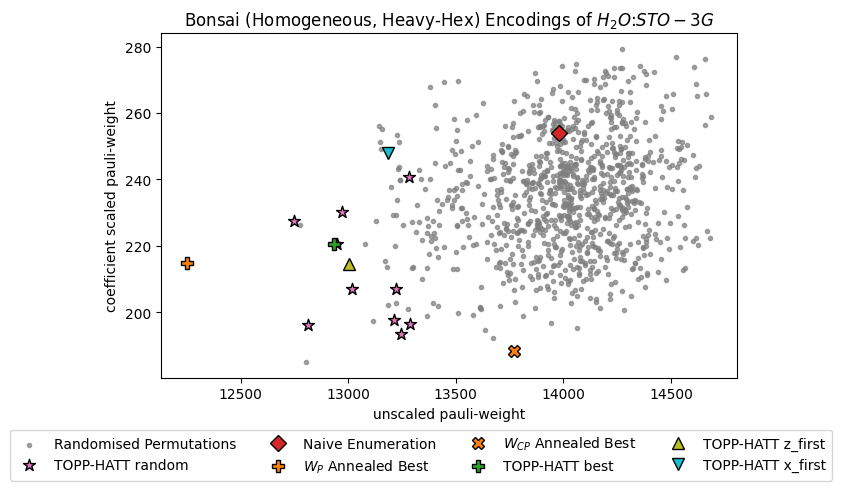

In [18]:
from ferrmion.optimize import bonsai_algorithm
bonsai= bonsai_algorithm(graph=graph, homogenous=True)
draw_tt(bonsai, type="spaced")
get_topp_hatt_results(bonsai, name="Bonsai (Homogeneous, Heavy-Hex)", ones=ones, twos=twos,  enuc=enuc)